Train shape: (800, 4)
Test shape : (200, 4)

QDA Accuracy: 0.965

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       104
           1       0.98      0.95      0.96        96

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200


Class probabilities:
[[9.67693599e-01 3.23064009e-02]
 [9.99981309e-01 1.86912101e-05]
 [9.78232599e-01 2.17674007e-02]
 [4.48047372e-07 9.99999552e-01]
 [9.99999987e-01 1.28936513e-08]]

Predictions:
[0 0 0 1 0]

Class means:
[[-0.0172363  -1.09232245  0.03077618 -1.22247189]
 [ 0.02036365  1.16204291  1.08968904  0.03074708]]

Number of covariance matrices:
2

Covariance matrix of Class 0:
[[ 9.56727442e-01 -4.66954363e-02 -1.02025248e-01 -1.83031907e-03]
 [-4.66954363e-02  8.06787969e-01  5.30973011e-01 -4.83987437e-01]
 [-1.02025248e-01  5.30973011e-01  2.59649376e+00 -2.7

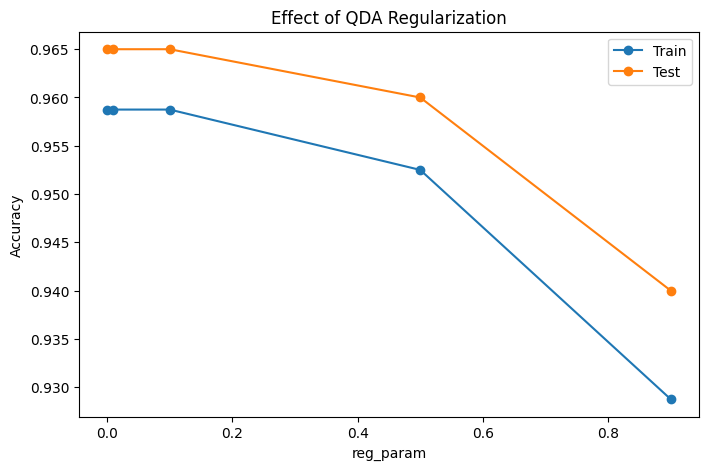

In [1]:
# ============================================================
# QDA — QUADRATIC DISCRIMINANT ANALYSIS 🟢
# ============================================================
#
# DEPTH:
#   🟢 Concept + sklearn
#
# No scratch implementation needed.
#
# Learn:
#   1. Why QDA?
#   2. Intuition
#   3. Gaussian assumption
#   4. Covariance matrices
#   5. QDA probability equation
#   6. Internal working
#   7. sklearn implementation
#   8. Important parameters
#   9. LDA vs QDA
#  10. Experiments
#  11. Advantages / disadvantages
#  12. Interview questions
#  13. 30-second explanation
#  14. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

from sklearn.discriminant_analysis import (
    QuadraticDiscriminantAnalysis
)


# ============================================================
# 2. WHY QDA?
# ============================================================
#
# QDA is a supervised classification algorithm.
#
# It is closely related to LDA.
#
#
# LDA assumes:
#
#     All classes share the SAME covariance matrix.
#
#     Σ0 = Σ1 = Σ
#
#     ↓
#
#     Linear decision boundary
#
#
# QDA assumes:
#
#     Each class has its OWN covariance matrix.
#
#     Σ0 != Σ1
#
#     ↓
#
#     More flexible decision boundary
#
#     ↓
#
#     Quadratic boundary
#
# ============================================================


# ============================================================
# 3. INTUITION ⭐⭐⭐
# ============================================================
#
# Imagine two classes.
#
#
# LDA:
#
#        ● ●
#       ● ● ●
#
#              |
#              |  Linear boundary
#              |
#                    ○ ○
#                   ○ ○ ○
#
#
# LDA assumes both classes have the same general covariance
# structure.
#
#
# QDA allows:
#
#
#       ● ●
#     ● ● ● ●
#      ● ●
#
#
#                       ○
#                    ○ ○ ○
#                   ○ ○ ○
#                     ○
#
#
# The two classes can have different:
#
#     spread
#     orientation
#     covariance
#
#
# Therefore QDA can create a curved/quadratic boundary.
#
# ============================================================


# ============================================================
# 4. GAUSSIAN ASSUMPTION ⭐⭐⭐
# ============================================================
#
# QDA assumes that the features for each class approximately
# follow a multivariate Gaussian distribution.
#
#
# For class k:
#
#     X | Y=k ~ N(μ_k, Σ_k)
#
#
# where:
#
#     μ_k = mean vector of class k
#
#     Σ_k = covariance matrix of class k
#
#
# IMPORTANT:
#
# Each class gets its own covariance matrix.
#
#
# Class 0:
#
#     μ0
#     Σ0
#
#
# Class 1:
#
#     μ1
#     Σ1
#
#
# Class 2:
#
#     μ2
#     Σ2
#
# ============================================================


# ============================================================
# 5. QDA vs LDA — THE MOST IMPORTANT CONCEPT ⭐⭐⭐
# ============================================================
#
#
# LDA:
#
#       Σ0 = Σ1 = Σ
#
#       Shared covariance
#
#             ↓
#
#       Linear boundary
#
#
# QDA:
#
#       Σ0 != Σ1
#
#       Separate covariance
#
#             ↓
#
#       Quadratic boundary
#
#
# EASY MEMORY:
#
#
#       LDA
#        ↓
#       Linear
#        ↓
#       Shared covariance
#
#
#       QDA
#        ↓
#       Quadratic
#        ↓
#       Separate covariance
#
# ============================================================


# ============================================================
# 6. QDA PROBABILITY IDEA
# ============================================================
#
# QDA uses Bayes theorem:
#
#
# P(Y=k | X)
#
#     ∝
#
# P(X | Y=k) * P(Y=k)
#
#
# Since:
#
#     X | Y=k
#
# follows a Gaussian distribution,
# QDA calculates the Gaussian likelihood for each class.
#
#
# Then:
#
#     likelihood × prior
#
# is compared across classes.
#
# The class with the highest posterior probability wins.
#
# ============================================================


# ============================================================
# 7. QDA DISCRIMINANT FUNCTION ⭐⭐
# ============================================================
#
# The QDA discriminant function can be written as:
#
#
# δ_k(x) =
#
# -1/2 log|Σ_k|
#
# -1/2 (x-μ_k)^T Σ_k^-1 (x-μ_k)
#
# + log P(Y=k)
#
#
# where:
#
#     μ_k      = class mean
#     Σ_k      = class covariance
#     |Σ_k|    = determinant
#     Σ_k^-1   = inverse covariance
#     P(Y=k)   = class prior
#
#
# IMPORTANT:
#
# You don't need to memorize every term.
#
# Remember:
#
# QDA calculates:
#
#     distance from class mean
#     +
#     covariance structure
#     +
#     class prior
#
# ============================================================


# ============================================================
# 8. WHY DOES QDA PRODUCE A QUADRATIC BOUNDARY?
# ============================================================
#
# Look at this term:
#
#
#     (x-μ_k)^T Σ_k^-1 (x-μ_k)
#
#
# Because x appears on both sides of the multiplication,
# expanding this expression creates terms such as:
#
#     x1²
#     x2²
#     x1*x2
#
#
# Therefore the decision boundary can contain quadratic
# terms.
#
#
# Hence:
#
#     QDA → Quadratic Decision Boundary
#
# ============================================================


# ============================================================
# 9. INTERNAL WORKING
# ============================================================
#
#
# Training:
#
# Training Data
#      ↓
# Separate samples by class
#      ↓
# Calculate mean for each class
#      ↓
# Calculate covariance for EACH class
#      ↓
# Calculate class priors
#      ↓
# Store parameters
#
#
# Prediction:
#
# New sample
#      ↓
# Calculate Gaussian likelihood
# for every class
#      ↓
# Multiply by class prior
#      ↓
# Calculate posterior score
#      ↓
# Choose highest score
#      ↓
# Prediction
#
# ============================================================


# ============================================================
# 10. CREATE DATASET
# ============================================================

X, y = make_classification(
    n_samples=1000,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


# ============================================================
# 11. BASIC QDA MODEL
# ============================================================

qda = QuadraticDiscriminantAnalysis()

qda.fit(
    X_train,
    y_train
)

pred = qda.predict(
    X_test
)

print(
    "\nQDA Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        pred
    )
)


# ============================================================
# 12. PREDICT PROBABILITIES
# ============================================================
#
# QDA can return posterior probabilities.
# ============================================================

probabilities = qda.predict_proba(
    X_test[:5]
)

print(
    "\nClass probabilities:"
)

print(probabilities)

print(
    "\nPredictions:"
)

print(
    qda.predict(
        X_test[:5]
    )
)


# ============================================================
# 13. IMPORTANT QDA PARAMETERS
# ============================================================
#
#
# ------------------------------------------------------------
# reg_param ⭐⭐⭐
# ------------------------------------------------------------
#
# Regularization parameter for covariance matrices.
#
# Range:
#
#     0 <= reg_param <= 1
#
#
# Conceptually:
#
#     reg_param = 0
#         → no covariance regularization
#
#
#     larger reg_param
#         → stronger regularization
#
#
# Regularization can help when covariance matrices are
# unstable or nearly singular.
#
#
# ------------------------------------------------------------
# priors
# ------------------------------------------------------------
#
# Prior probabilities of classes.
#
# Example:
#
# priors=[0.7, 0.3]
#
#
# If None:
#
#     priors are estimated from training data.
#
#
# ------------------------------------------------------------
# store_covariance
# ------------------------------------------------------------
#
# Whether to store covariance matrices.
#
# Useful if you want to inspect them.
#
#
# ------------------------------------------------------------
# tol
# ------------------------------------------------------------
#
# Threshold for rank estimation when using SVD.
#
# ============================================================


# ============================================================
# 14. INSPECT CLASS MEANS
# ============================================================
#
# QDA stores class means.
# ============================================================

print(
    "\nClass means:"
)

print(
    qda.means_
)


# ============================================================
# 15. INSPECT CLASS COVARIANCE
# ============================================================
#
# With store_covariance=True, we can inspect the covariance
# matrix for each class.
# ============================================================

qda_cov = QuadraticDiscriminantAnalysis(
    store_covariance=True
)

qda_cov.fit(
    X_train,
    y_train
)

print(
    "\nNumber of covariance matrices:"
)

print(
    len(qda_cov.covariance_)
)

print(
    "\nCovariance matrix of Class 0:"
)

print(
    qda_cov.covariance_[0]
)

print(
    "\nCovariance matrix of Class 1:"
)

print(
    qda_cov.covariance_[1]
)


# ============================================================
# 16. REGULARIZATION
# ============================================================
#
# QDA estimates a separate covariance matrix for each class.
#
# If we have:
#
#     Many features
#         +
#     Few samples
#
# covariance estimation can become unstable.
#
#
# Regularization can help.
#
# ============================================================

qda_regularized = QuadraticDiscriminantAnalysis(
    reg_param=0.1
)

qda_regularized.fit(
    X_train,
    y_train
)

regularized_pred = qda_regularized.predict(
    X_test
)

print(
    "\nRegularized QDA Accuracy:",
    accuracy_score(
        y_test,
        regularized_pred
    )
)


# ============================================================
# 17. EXPERIMENT — REGULARIZATION
# ============================================================

reg_values = [
    0.0,
    0.01,
    0.1,
    0.5,
    0.9
]

train_scores = []
test_scores = []

for reg in reg_values:

    model = QuadraticDiscriminantAnalysis(
        reg_param=reg
    )

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    train_scores.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    test_scores.append(
        accuracy_score(
            y_test,
            test_pred
        )
    )


plt.figure(figsize=(8, 5))

plt.plot(
    reg_values,
    train_scores,
    marker="o",
    label="Train"
)

plt.plot(
    reg_values,
    test_scores,
    marker="o",
    label="Test"
)

plt.xlabel("reg_param")
plt.ylabel("Accuracy")

plt.title(
    "Effect of QDA Regularization"
)

plt.legend()

plt.show()


# ============================================================
# 18. QDA vs LDA — COMPLETE COMPARISON ⭐⭐⭐
# ============================================================
#
#
#                         Discriminant Analysis
#                                  │
#                    ┌─────────────┴─────────────┐
#                    │                           │
#                    ▼                           ▼
#                   LDA                         QDA
#                    │                           │
#                    ▼                           ▼
#             Shared covariance          Separate covariance
#                    │                           │
#                    ▼                           ▼
#             Σ0 = Σ1 = Σ               Σ0 != Σ1
#                    │                           │
#                    ▼                           ▼
#            Linear boundary          Quadratic boundary
#                    │                           │
#                    ▼                           ▼
#              Less flexible               More flexible
#                    │                           │
#                    ▼                           ▼
#             Lower variance              Higher variance
#                                             risk
#
#
# ============================================================


# ============================================================
# 19. LDA vs QDA — TABLE
# ============================================================
#
# | Property             | LDA             | QDA             |
# |----------------------|-----------------|-----------------|
# | Full name            | Linear DA       | Quadratic DA    |
# | Model                | Generative      | Generative      |
# | Distribution         | Gaussian        | Gaussian        |
# | Covariance           | Shared          | Separate        |
# | Boundary             | Linear          | Quadratic       |
# | Flexibility          | Lower           | Higher          |
# | Parameters           | Fewer           | More            |
# | Overfitting risk     | Lower           | Higher          |
# | Data requirement     | Lower           | Higher          |
#
# ============================================================


# ============================================================
# 20. QDA vs LOGISTIC REGRESSION
# ============================================================
#
# Logistic Regression:
#
#     Discriminative
#     Directly models P(Y | X)
#     Linear boundary
#
#
# QDA:
#
#     Generative
#     Models P(X | Y) and P(Y)
#     Gaussian assumption
#     Separate covariance
#     Quadratic boundary
#
#
# ============================================================


# ============================================================
# 21. QDA vs NAIVE BAYES
# ============================================================
#
# Both are probabilistic/generative approaches.
#
#
# Naive Bayes:
#
#     Assumes conditional independence between features.
#
#     Covariance structure is effectively diagonal.
#
#
# QDA:
#
#     Allows correlations between features.
#
#     Each class can have a full covariance matrix.
#
#
# Therefore:
#
#     QDA is more flexible.
#
# But:
#
#     QDA needs more data to reliably estimate covariance
#     matrices.
#
# ============================================================


# ============================================================
# 22. WHEN SHOULD YOU USE QDA?
# ============================================================
#
# QDA can be useful when:
#
#     1. Classes are reasonably Gaussian.
#
#     2. Different classes have different covariance
#        structures.
#
#     3. A nonlinear/quadratic boundary is useful.
#
#     4. You have enough data to estimate covariance
#        matrices reliably.
#
#
# Example:
#
# Class 0:
#     narrow distribution
#
# Class 1:
#     wide / differently oriented distribution
#
# QDA can model this difference.
#
# ============================================================


# ============================================================
# 23. WHEN CAN QDA STRUGGLE?
# ============================================================
#
# QDA can struggle when:
#
#     Many features
#         +
#     Small dataset
#
#
# Why?
#
# Each class needs its own covariance matrix.
#
#
# Number of covariance parameters increases rapidly with
# number of features.
#
#
# Therefore:
#
#     High dimensionality
#          ↓
#     unstable covariance estimation
#          ↓
#     possible overfitting
#
#
# Regularization can help.
#
# ============================================================


# ============================================================
# 24. ADVANTAGES
# ============================================================
#
# 1. More flexible than LDA.
#
# 2. Can model quadratic decision boundaries.
#
# 3. Allows different covariance structures for classes.
#
# 4. Probabilistic interpretation.
#
# 5. Fast for moderate-sized datasets.
#
# ============================================================


# ============================================================
# 25. DISADVANTAGES
# ============================================================
#
# 1. More parameters than LDA.
#
# 2. Higher overfitting risk.
#
# 3. Needs more data.
#
# 4. Covariance estimation can become unstable.
#
# 5. Gaussian assumption may not hold.
#
# ============================================================


# ============================================================
# 26. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is QDA?
#
# Answer:
#
# QDA is a generative classification algorithm that assumes
# each class follows a Gaussian distribution with its own
# covariance matrix.
#
#
# ------------------------------------------------------------
#
# Q2. Why is QDA called quadratic?
#
# Answer:
#
# Because the class discriminant functions contain quadratic
# terms in the features, producing quadratic decision
# boundaries.
#
#
# ------------------------------------------------------------
#
# Q3. What is the main difference between LDA and QDA?
#
# Answer:
#
# LDA assumes all classes share one covariance matrix.
# QDA estimates a separate covariance matrix for every class.
#
#
# ------------------------------------------------------------
#
# Q4. Why does LDA produce a linear boundary?
#
# Answer:
#
# Because the shared covariance terms cancel when comparing
# class discriminant functions.
#
#
# ------------------------------------------------------------
#
# Q5. Why can QDA overfit more than LDA?
#
# Answer:
#
# QDA estimates a separate covariance matrix for every class,
# resulting in many more parameters.
#
#
# ------------------------------------------------------------
#
# Q6. What is reg_param?
#
# Answer:
#
# It regularizes the class covariance matrices to improve
# numerical stability and reduce overfitting.
#
#
# ------------------------------------------------------------
#
# Q7. QDA vs Logistic Regression?
#
# Answer:
#
# Logistic Regression is discriminative and directly models
# P(Y|X), while QDA is generative and models P(X|Y) and P(Y)
# under Gaussian assumptions.
#
#
# ------------------------------------------------------------
#
# Q8. QDA vs Naive Bayes?
#
# Answer:
#
# Naive Bayes assumes conditional independence between
# features, while QDA can model correlations through a
# full covariance matrix for each class.
#
#
# ============================================================


# ============================================================
# 27. 30-SECOND INTERVIEW EXPLANATION ⭐⭐⭐
# ============================================================
#
# QDA is a generative classification algorithm that assumes
# each class follows a Gaussian distribution with its own
# covariance matrix.
#
# Unlike LDA, which assumes a shared covariance matrix,
# QDA allows each class to have a different covariance
# structure. This gives QDA more flexibility and produces
# quadratic decision boundaries, but also increases the
# number of parameters and overfitting risk.
#
# ============================================================


# ============================================================
# 28. FINAL MEMORY CHEATSHEET
# ============================================================
#
# QDA =
#
# Gaussian distributions
#       +
# Separate covariance per class
#       +
# Bayes theorem
#       +
# Quadratic boundary
#
#
# MUST REMEMBER:
#
# 1. QDA = Quadratic Discriminant Analysis
#
# 2. Supervised classification
#
# 3. Generative model
#
# 4. Assumes Gaussian class distributions
#
# 5. Each class has its own covariance:
#
#       Σ0 != Σ1
#
# 6. Produces quadratic decision boundaries
#
# 7. More flexible than LDA
#
# 8. More parameters than LDA
#
# 9. Higher overfitting risk
#
# 10. reg_param controls covariance regularization
#
# ============================================================


# ============================================================
# 29. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                         QDA
#                          │
#                          ▼
#                    Training Data
#                          │
#                          ▼
#                    Separate Classes
#                          │
#              ┌───────────┼───────────┐
#              │           │           │
#              ▼           ▼           ▼
#           Class 0      Class 1     Class K
#              │           │           │
#              ▼           ▼           ▼
#            Mean        Mean         Mean
#              │           │           │
#              ▼           ▼           ▼
#         Covariance   Covariance   Covariance
#             Σ0           Σ1           Σk
#              │           │           │
#              └───────────┼───────────┘
#                          │
#                          ▼
#                    Class Priors
#                          │
#                          ▼
#                     New Sample
#                          │
#                          ▼
#               Gaussian Likelihood
#                  for each class
#                          │
#                          ▼
#                  × Class Prior
#                          │
#                          ▼
#                 Posterior / Score
#                          │
#                          ▼
#               Highest Probability
#                          │
#                          ▼
#                     Prediction
#
#
# ============================================================
#
# LDA vs QDA TREE:
#
#
#                   Discriminant Analysis
#                           │
#                 ┌─────────┴─────────┐
#                 │                   │
#                 ▼                   ▼
#                LDA                 QDA
#                 │                   │
#                 ▼                   ▼
#        Shared covariance     Separate covariance
#                 │                   │
#                 ▼                   ▼
#          Σ0 = Σ1 = Σ         Σ0 != Σ1
#                 │                   │
#                 ▼                   ▼
#         Linear boundary      Quadratic boundary
#                 │                   │
#                 ▼                   ▼
#        Less parameters       More parameters
#                 │                   │
#                 ▼                   ▼
#        Lower flexibility     Higher flexibility
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     LDA:
#         "All classes have the same shape,
#          but different centers."
#
#
#     QDA:
#         "Each class can have its own shape
#          and center."
#
# ============================================================